# **INFO 6154 - Machine Learning Optimization**
### **Final Project - Stock Market Predictions**
### **Student Name:** Bernardo Silva
### **Student ID:** 1229489

# **CREATE A INTRO TEXT ABOUT THE PROJECT**

# **Basic config**

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 19.8 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Class config
class Config():
    # Load
    PATH = '/content/b3_stocks_1994_2020_PETR3.csv' # Update with the correct file path
    # Training
    EPOCHS = 100

    # Optimization
    N_TRIALS = 5

config = Config()

# **Load Data**

This section focuses on loading the dataset into a pandas DataFrame and performing initial inspection.

We'll verify the data structure, check for missing values, and ensure the data types are appropriate for our analysis.

In [5]:
# Load the dataset
df = pd.read_csv(config.PATH)

# drop column ticker
df.drop('ticker', axis=1, inplace=True)

# Display basic info
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
df.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5640 entries, 0 to 5639
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  5640 non-null   object 
 1   open      5640 non-null   float64
 2   close     5640 non-null   float64
 3   high      5640 non-null   float64
 4   low       5640 non-null   float64
 5   volume    5640 non-null   float64
dtypes: float64(5), object(1)
memory usage: 264.5+ KB
None

First 5 rows:


,datetime,open,close,high,low,volume
0,1998-03-16,218.0,215.03,218.0,215.0,724584.3
1,1998-03-17,216.0,219.00,219.0,216.0,953560.1
2,1998-03-18,219.0,218.00,220.5,218.0,5008169.7
3,1998-03-19,217.0,224.90,224.9,214.0,2604468.3
4,1998-03-20,223.5,216.00,223.5,214.0,1824445.1


In [6]:
# Convert datetime column to datetime and set as index
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df.head()

,open,close,high,low,volume
datetime,,,,,
1998-03-16,218.0,215.03,218.0,215.0,724584.3
1998-03-17,216.0,219.00,219.0,216.0,953560.1
1998-03-18,219.0,218.00,220.5,218.0,5008169.7
1998-03-19,217.0,224.90,224.9,214.0,2604468.3
1998-03-20,223.5,216.00,223.5,214.0,1824445.1


# **Data Overview and Visualization**

This section provides a comprehensive statistical summary of the dataset and creates visualizations to understand price trends, volume patterns, and relationships between different features.

##### **Basic statistics**

In [7]:
# Basic statistics
print("\nSummary Statistics:")
display(df.describe(include='all').T)


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
open,5640.0,5.742605e+01,6.935932e+01,5.89,20.20,3.715000e+01,5.850250e+01,4.800000e+02
close,5640.0,5.745146e+01,6.948311e+01,5.91,20.21,3.712000e+01,5.850000e+01,4.940000e+02
high,5640.0,5.835621e+01,7.049769e+01,5.99,20.64,3.783500e+01,5.950000e+01,4.949900e+02
low,5640.0,5.644346e+01,6.811128e+01,5.67,19.92,3.640000e+01,5.780000e+01,4.800000e+02
volume,5640.0,1.343865e+08,1.673126e+08,2560.00,25596168.80,9.959608e+07,1.789497e+08,4.318598e+09


##### **Closing Price Trend**

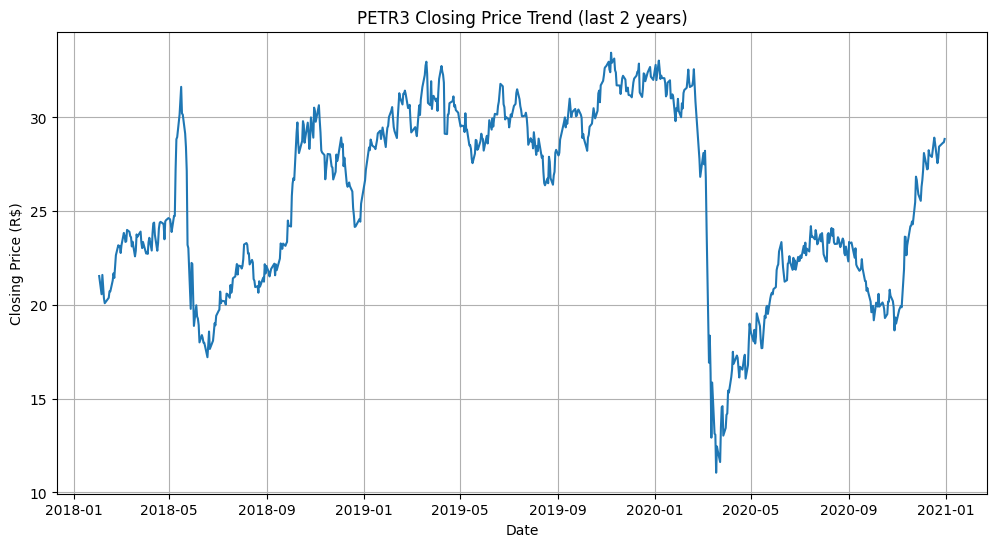

In [8]:
# Closing Price Trend - last 2 years

plt.figure(figsize=(12, 6))
# get the last 720 days
last_720_days = df['close'].tail(720)
# plot the closing price trend
plt.plot(last_720_days.index, last_720_days.values)
plt.title('PETR3 Closing Price Trend (last 2 years)')
plt.xlabel('Date')
plt.ylabel('Closing Price (R$)')
plt.grid(True)
plt.show()

##### **Volume Distribution**

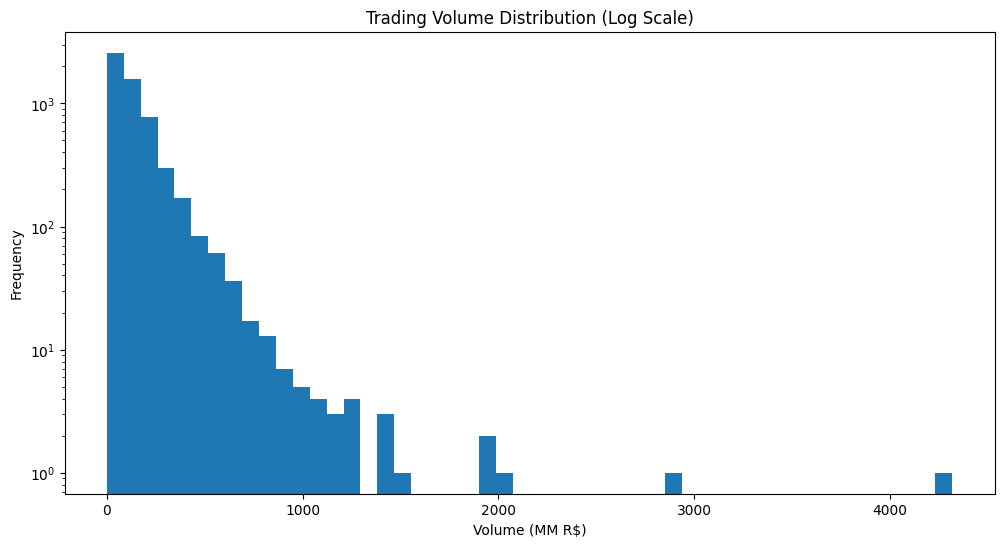

In [9]:
# Plot the 'volume' in millions - y-axis in %
plt.figure(figsize=(12, 6))
plt.hist(df['volume'].div(1e6), bins=50, log=True)
plt.title('Trading Volume Distribution (Log Scale)')
plt.xlabel('Volume (MM R$)')
plt.ylabel('Frequency')
plt.show()

##### **Daily Price Range**

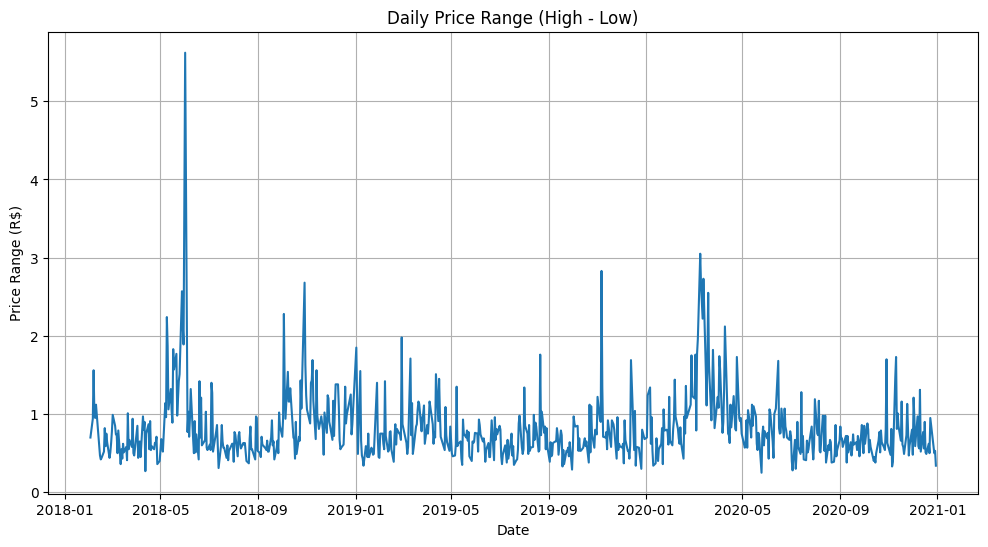

In [10]:
df['daily_range'] = df['high'] - df['low']
plt.figure(figsize=(12, 6))
plt.plot(df.tail(720).index, df['daily_range'].tail(720))
plt.title('Daily Price Range (High - Low)')
plt.xlabel('Date')
plt.ylabel('Price Range (R$)')
plt.grid(True)
plt.show()

##### **Monthly Average Closing Price**

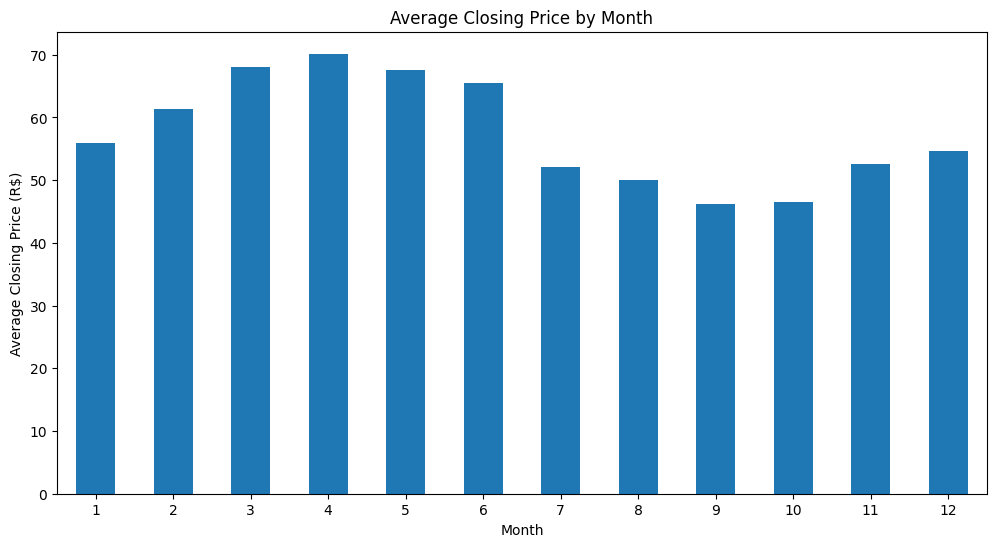

In [11]:
df['month'] = df.index.month
monthly_avg = df.groupby('month')['close'].mean()
plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar')
plt.title('Average Closing Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (R$)')
plt.xticks(rotation=0)
plt.show()

# **Data preparation**

This section prepares the data for modeling by converting data types, creating features, and splitting the dataset into training, validation, and test sets.

In [12]:
# Create target variable (next day's closing price)
df['target'] = df['close'].shift(-1)

# Remove the last row which will have NaN for target
df = df[:-1]

df.head()

,open,close,high,low,volume,daily_range,month,target
datetime,,,,,,,,
1998-03-16,218.0,215.03,218.0,215.0,724584.3,3.0,3,219.0
1998-03-17,216.0,219.00,219.0,216.0,953560.1,3.0,3,218.0
1998-03-18,219.0,218.00,220.5,218.0,5008169.7,2.5,3,224.9
1998-03-19,217.0,224.90,224.9,214.0,2604468.3,10.9,3,216.0
1998-03-20,223.5,216.00,223.5,214.0,1824445.1,9.5,3,213.0


##### **Feature engineering**

In [13]:
# Create Technical Indicators
df['sma_5'] = df['close'].rolling(window=5).mean()  # 5-day simple moving average
df['sma_20'] = df['close'].rolling(window=20).mean()  # 20-day simple moving average
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()  # 12-day exponential moving average
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()  # 26-day exponential moving average
df['macd'] = df['ema_12'] - df['ema_26']  # MACD line

# Calculate RSI
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))

# Lag features
for i in [1, 2, 3, 5, 7]:  # 1, 2, 3, 5, and 7-day lags
    df[f'lag_{i}'] = df['close'].shift(i)

# Volume features
df['volume_ma_5'] = df['volume'].rolling(window=5).mean()
df['volume_ma_20'] = df['volume'].rolling(window=20).mean()
df['volume_change'] = df['volume'].pct_change()

# Date-based features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter

# Handle volume outliers using winsorization
volume_q1 = df['volume'].quantile(0.05)
volume_q3 = df['volume'].quantile(0.95)
df['volume'] = np.where(df['volume'] < volume_q1, volume_q1,
                       np.where(df['volume'] > volume_q3, volume_q3, df['volume']))

# Drop rows with NaN values (created by rolling windows and lags)
df.dropna(inplace=True)

df.head()

,open,close,high,low,volume,daily_range,month,target,sma_5,sma_20,...,lag_1,lag_2,lag_3,lag_5,lag_7,volume_ma_5,volume_ma_20,volume_change,day_of_week,quarter
datetime,,,,,,,,,,,,,,,,,,,,,
1998-04-14,221.0,232.0,232.0,221.0,2603540.47,11.0,4,232.0,215.502,211.4220,...,219.0,213.51,208.00,201.00,200.0,1228586.48,1799437.100,0.516778,1,2
1998-04-15,230.0,232.0,235.0,226.0,2603540.47,9.0,4,235.0,220.902,212.2705,...,232.0,219.00,213.51,205.00,207.0,1265994.36,1834314.910,-0.010855,2,2
1998-04-16,230.0,235.0,235.0,228.0,2603540.47,7.0,4,228.0,226.302,213.0705,...,232.0,232.00,219.00,208.00,201.0,1131001.36,1809976.905,-0.671762,3,2
1998-04-17,227.0,228.0,228.0,222.0,2603540.47,6.0,4,226.0,229.200,213.5705,...,235.0,232.00,232.00,213.51,205.0,987734.98,1592773.060,0.422650,4,2
1998-04-20,229.0,226.0,229.0,223.0,2603540.47,6.0,4,222.0,230.600,213.6255,...,228.0,235.00,232.00,219.00,208.0,1153817.98,1551465.145,1.677803,0,2


In [14]:
# Separate features by type
# Define feature groups
PRICE_FEATURES = ['open','close','high','low','target','sma_5','sma_20',
                 'ema_12','ema_26','macd','rsi','lag_1','lag_2','lag_3',
                 'lag_5','lag_7']
VOLUME_FEATURES = ['volume','volume_ma_5','volume_ma_20','volume_change']
RANGE_FEATURES = ['daily_range']
CATEGORICAL_FEATURES = ['day_of_week','month','quarter']

In [15]:
# Scaling features
features = df.drop(columns=['target'])
target = df['target'].values

# Scale features and target separately
feature_scaler = RobustScaler()
scaled_features = feature_scaler.fit_transform(features)

target_scaler = RobustScaler()
scaled_target = target_scaler.fit_transform(target.reshape(-1, 1)).flatten()

##### **Split data - train/val/test**

In [16]:
# Split data chronologically
train_size = int(0.7 * len(scaled_features))
val_size = int(0.15 * len(scaled_features))

# Use array slicing instead of .iloc for NumPy arrays
X_train = scaled_features[:train_size]
y_train = scaled_target[:train_size]
X_val = scaled_features[train_size:train_size+val_size]
y_val = scaled_target[train_size:train_size+val_size]
X_test = scaled_features[train_size+val_size:]
y_test = scaled_target[train_size+val_size:]

print(f"Training set: {len(X_train)} samples") # Changed train_df to X_train
print(f"Validation set: {len(X_val)} samples") # Changed val_df to X_val
print(f"Test set: {len(X_test)} samples") # Changed test_df to X_test

Training set: 3933 samples
Validation set: 843 samples
Test set: 844 samples


# **Applying Window Sequencing**

We will create sequences of input/output for the LSTM model.

In [17]:
# Parameters Configuration
LOOKBACK = 48  # Input sequence length (48 days)
FORECAST = 24  # Prediction horizon (24 days)

# Create Multi-Step Sequences
def create_multi_step_sequences(X, y, lookback=LOOKBACK, forecast=FORECAST):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback - forecast + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback:i+lookback+forecast])
    return np.array(X_seq), np.array(y_seq)

In [18]:
# Create sequences for train/val/test
X_train_seq, y_train_seq = create_multi_step_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_multi_step_sequences(X_val, y_val)
X_test_seq, y_test_seq = create_multi_step_sequences(X_test, y_test)

print(f"Training sequences: {X_train_seq.shape} -> {y_train_seq.shape}")
print(f"Validation sequences: {X_val_seq.shape} -> {y_val_seq.shape}")
print(f"Test sequences: {X_test_seq.shape} -> {y_test_seq.shape}")

Training sequences: (3862, 48, 23) -> (3862, 24)
Validation sequences: (772, 48, 23) -> (772, 24)
Test sequences: (773, 48, 23) -> (773, 24)


# **Model development**

This section focuses on building and training the LSTM model.

We'll start with a baseline model, then use Optuna for hyperparameter tuning to find the optimal architecture.

In [19]:
def build_baseline_model(input_shape, forecast_horizon=24):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(forecast_horizon)  # Output 24 values directly
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [20]:
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
baseline_model = build_baseline_model(input_shape)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 64)              │          22,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24)                  │             792 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,736 (139.59 KB)

 Trainable params: 35,736 (139.59 KB)

 Non-trainable params: 0 (0.00 B)

##### **Train baseline model**

In [21]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Increased patience for sequence learning
    min_delta=0.001,  # Minimum change to qualify as improvement
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    # 'best_model.h5',
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
)

# Custom Metrics for Sequence Prediction
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Training Loop
start_time = time.time()

history = baseline_model.fit(
    X_train_seq,  # Shape: (samples, 48, features)
    y_train_seq,   # Shape: (samples, 24)
    validation_data=(X_val_seq, y_val_seq),
    epochs=config.EPOCHS,
    batch_size=64,  # Larger batch for sequence learning
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

baseline_model_time = time.time() - start_time

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - loss: 4.0012 - val_loss: 0.0677
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.0208 - val_loss: 0.0279
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3682 - val_loss: 0.0169
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0675 - val_loss: 0.0172
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8879 - val_loss: 0.0198
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7610 - val_loss: 0.0228
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6251 - val_loss: 0.0205
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5879 - val_loss: 0.0186
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5210 - val_loss: 0.0159
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4675 - val_loss: 0.0155
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4274 - val_loss: 0.0240
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

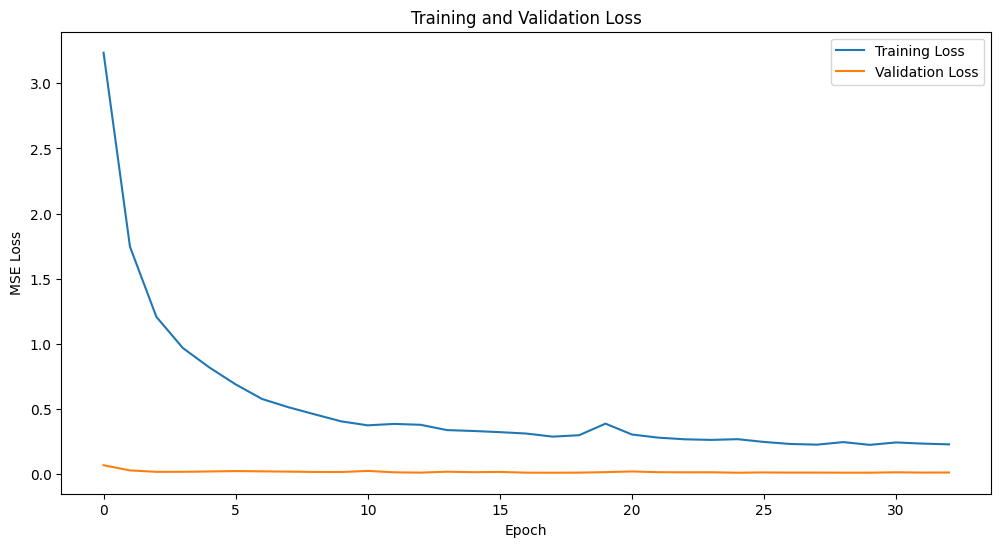

In [22]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# **Hyperparameter tuning with Optuna**

In [23]:
# Define objective function
def objective(trial):
    # Define hyperparameters to tune
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_categorical('units', [32, 64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])

    # Build model
    model = Sequential()
    model.add(LSTM(units, return_sequences=(n_layers > 1), input_shape=input_shape))
    model.add(Dropout(dropout_rate))

    for i in range(1, n_layers):
        if i == n_layers - 1:
            model.add(LSTM(units))
        else:
            model.add(LSTM(units, return_sequences=True))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    # Compile model
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')

    # Train model
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=config.EPOCHS,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    return min(history.history['val_loss'])

In [24]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=config.N_TRIALS)
# study.optimize(objective, n_trials=30)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  Value (MSE): {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-03-30 22:45:54,439] A new study created in memory with name: no-name-8d01ff60-bdde-4932-8245-39ac302f2b46
[I 2025-03-30 22:46:56,596] Trial 0 finished with value: 0.009365501813590527 and parameters: {'n_layers': 1, 'units': 32, 'dropout_rate': 0.18247300407639755, 'learning_rate': 0.0027625024057010483, 'batch_size': 16}. Best is trial 0 with value: 0.009365501813590527.
[I 2025-03-30 22:47:12,221] Trial 1 finished with value: 0.003220057813450694 and parameters: {'n_layers': 1, 'units': 256, 'dropout_rate': 0.16325909245900405, 'learning_rate': 0.0039252690529871055, 'batch_size': 64}. Best is trial 1 with value: 0.003220057813450694.
[I 2025-03-30 22:47:48,435] Trial 2 finished with value: 0.01768672838807106 and parameters: {'n_layers': 2, 'units': 32, 'dropout_rate': 0.140305801217827, 'learning_rate': 9.35768685192838e-05, 'batch_size': 64}. Best is trial 1 with value: 0.003220057813450694.
[I 2025-03-30 22:48:18,455] Trial 3 finished with value: 0.0032879277132451534 and

Best trial:
  Value (MSE): 0.003220057813450694
  Params: 
    n_layers: 1
    units: 256
    dropout_rate: 0.16325909245900405
    learning_rate: 0.0039252690529871055
    batch_size: 64


In [25]:
def build_final_model(params, input_shape, forecast_steps=24):
    model = Sequential()
    model.add(LSTM(params['units'], return_sequences=(params['n_layers'] > 1),
                  input_shape=input_shape))
    model.add(Dropout(params['dropout_rate']))

    for i in range(1, params['n_layers']):
        if i == params['n_layers'] - 1:
            model.add(LSTM(params['units']))
        else:
            model.add(LSTM(params['units'], return_sequences=True))
        model.add(Dropout(params['dropout_rate']))

    # Change output layer to predict multiple steps
    model.add(Dense(forecast_steps))  # Now outputs [batch_size, 24]

    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Rebuild with 24-step output
final_model = build_final_model(trial.params, input_shape, forecast_steps=24)

In [26]:
# Train final model
start_time = time.time()
history_final = final_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=config.EPOCHS,
    batch_size=trial.params['batch_size'],
    callbacks=[early_stopping],
    verbose=1
)
final_model_time = time.time() - start_time

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7796 - val_loss: 0.0184
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8803 - val_loss: 0.0113
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8398 - val_loss: 0.0122
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8104 - val_loss: 0.0123
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8136 - val_loss: 0.0124
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7515 - val_loss: 0.0129
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7137 - val_loss: 0.0163
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7845 - val_loss: 0.0079
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7510 - val_loss: 0.0092
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6969 - val_loss: 0.0071
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7546 - val_loss: 0.0062
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 

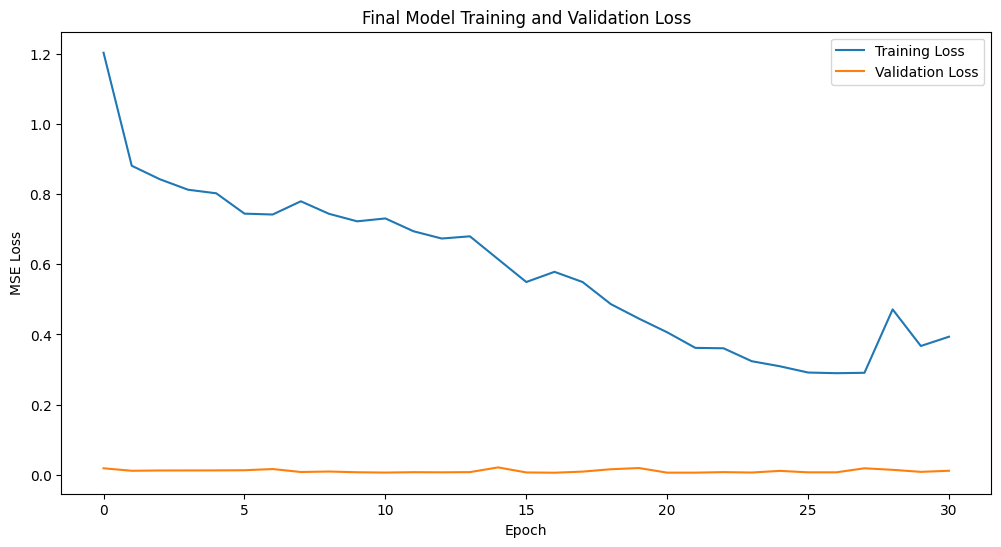

In [27]:
# Plot training history for final model
plt.figure(figsize=(12, 6))
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Final Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# **Model Evaluation**

This section evaluates the model's performance on the test set using various metrics and visualizes the predictions against actual values.

In [28]:
def calculate_metrics(model, X, y_true, train_time=None):
    """
    Calculates metrics for multi-step forecasting models.

    Args:
        model: Trained model (should output [samples, forecast_steps])
        X: Input data (shape: [samples, lookback_steps, features])
        y_true: True values (shape: [samples, forecast_steps])
        train_time: Training time in seconds (optional)

    Returns:
        Dictionary of metrics
    """
    # Get predictions (shape: [samples, forecast_steps])
    y_pred = model.predict(X)

    # Verify shapes
    if y_pred.shape != y_true.shape:
        raise ValueError(f"Shape mismatch: y_pred {y_pred.shape} vs y_true {y_true.shape}")

    # Calculate metrics
    metrics = {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': np.nanmean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100,
        'SMAPE': 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)),
        'R2': r2_score(y_true, y_pred),
        'Training_Time': train_time,
        'Model_Loss': model.evaluate(X, y_true, verbose=0)  # No [0] indexing
    }

    # Custom accuracy metric
    metrics['Accuracy'] = 1 - metrics['MAE']/np.mean(y_true)

    # Hyperparameters extraction (simplified)
    metrics['Hyperparameters'] = {
        'n_layers': len([l for l in model.layers if isinstance(l, LSTM)]),
        'units': [l.units for l in model.layers if isinstance(l, LSTM)],
        'dropout_rate': next((l.rate for l in model.layers if isinstance(l, Dropout)), None),
        'learning_rate': float(model.optimizer.learning_rate)
    }

    return metrics

In [29]:
# Calculate metrics for baseline model
baseline_metrics = calculate_metrics(baseline_model, X_test_seq, y_test_seq, baseline_model_time)
# baseline_metrics['Accuracy'] = 1 - baseline_metrics['MAE']/np.mean(y_test_seq)  # Custom accuracy metric
# baseline_metrics['n_layers'] = 2
# baseline_metrics['units'] = '64, 32'
# baseline_metrics['dropout_rate'] = 0.2
# baseline_metrics['learning_rate'] = 0.001
# baseline_metrics['batch_size'] = 32
baseline_metrics

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


{'MSE': 0.025738576745441683,
 'MAE': 0.12770622426589673,
 'MAPE': np.float64(55.26096161968045),
 'SMAPE': np.float64(41.25945026097646),
 'R2': -0.40274740237946133,
 'Training_Time': 35.503002643585205,
 'Model_Loss': 0.02573857642710209,
 'Accuracy': np.float64(1.4135669965803488),
 'Hyperparameters': {'n_layers': 2,
  'units': [64, 32],
  'dropout_rate': 0.2,
  'learning_rate': 0.0010000000474974513}}

In [30]:
# Calculate metrics for final model
final_metrics = calculate_metrics(final_model, X_test_seq, y_test_seq, final_model_time)
# final_metrics['Accuracy'] = 1 - final_metrics['MAE']/np.mean(y_test_seq)
# final_metrics['Hyperparameters'] = {
#     'n_layers': trial.params['n_layers'],
#     'units': trial.params['units'],
#     'dropout_rate': trial.params['dropout_rate'],
#     'learning_rate': trial.params['learning_rate'],
#     'batch_size': trial.params['batch_size']
# }
final_metrics

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


{'MSE': 0.015635581207781163,
 'MAE': 0.08633198299580902,
 'MAPE': np.float64(34.06880600571942),
 'SMAPE': np.float64(29.51736221435295),
 'R2': 0.1438586400585136,
 'Training_Time': 20.369024753570557,
 'Model_Loss': 0.01563558168709278,
 'Accuracy': np.float64(1.2795796299016966),
 'Hyperparameters': {'n_layers': 1,
  'units': [256],
  'dropout_rate': 0.16325909245900405,
  'learning_rate': 0.00392526900395751}}

In [31]:
# Prepare the metrics for comparison
comparison_data = {
    'Metric': ['MSE', 'MAE', 'MAPE (%)', 'SMAPE (%)', 'R²', 'Accuracy', 'Training Time (s)', 'Model Loss',
               'n_layers', 'units', 'dropout_rate', 'learning_rate'],
    'Baseline Model': [
        baseline_metrics['MSE'],
        baseline_metrics['MAE'],
        baseline_metrics['MAPE'],
        baseline_metrics['SMAPE'],
        baseline_metrics['R2'],
        baseline_metrics['Accuracy'],
        baseline_metrics['Training_Time'],
        baseline_metrics['Model_Loss'],
        baseline_metrics['Hyperparameters']['n_layers'],
        ', '.join(map(str, baseline_metrics['Hyperparameters']['units'])),
        baseline_metrics['Hyperparameters']['dropout_rate'],
        baseline_metrics['Hyperparameters']['learning_rate']
    ],
    'Final Model': [
        final_metrics['MSE'],
        final_metrics['MAE'],
        final_metrics['MAPE'],
        final_metrics['SMAPE'],
        final_metrics['R2'],
        final_metrics['Accuracy'],
        final_metrics['Training_Time'],
        final_metrics['Model_Loss'],
        final_metrics['Hyperparameters']['n_layers'],
        ', '.join(map(str, final_metrics['Hyperparameters']['units'])),
        final_metrics['Hyperparameters']['dropout_rate'],
        final_metrics['Hyperparameters']['learning_rate']
    ]
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,Baseline Model,Final Model
0,MSE,0.025739,0.015636
1,MAE,0.127706,0.086332
2,MAPE (%),55.260962,34.068806
3,SMAPE (%),41.25945,29.517362
4,R²,-0.402747,0.143859
5,Accuracy,1.413567,1.27958
6,Training Time (s),35.503003,20.369025
7,Model Loss,0.025739,0.015636
8,n_layers,2,1
9,units,"64, 32",256


In [32]:
# Calculate improvement percentages
def calculate_improvement(baseline, final):
    if isinstance(baseline, (int, float)) and isinstance(final, (int, float)):
        if baseline == 0:
            return 'N/A'
        improvement = ((baseline - final) / baseline) * 100
        return f"{improvement:.1f}%"
    return 'N/A'

In [33]:
comparison_df['Improvement'] = [
    calculate_improvement(baseline, final)
    for baseline, final in zip(comparison_df['Baseline Model'], comparison_df['Final Model'])
]

In [34]:
# Format numeric columns
numeric_cols = ['MSE', 'MAE', 'MAPE (%)', 'SMAPE (%)', 'R²', 'Accuracy', 'Training Time (s)', 'Model Loss']
for col in numeric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = comparison_df[col].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)

In [35]:
# Display the comparison
print("Model Performance Comparison:")
comparison_df

Model Performance Comparison:


,Metric,Baseline Model,Final Model,Improvement
0,MSE,0.025739,0.015636,39.3%
1,MAE,0.127706,0.086332,32.4%
2,MAPE (%),55.260962,34.068806,38.3%
3,SMAPE (%),41.25945,29.517362,28.5%
4,R²,-0.402747,0.143859,135.7%
5,Accuracy,1.413567,1.27958,9.5%
6,Training Time (s),35.503003,20.369025,42.6%
7,Model Loss,0.025739,0.015636,39.3%
8,n_layers,2,1,50.0%
9,units,"64, 32",256,N/A


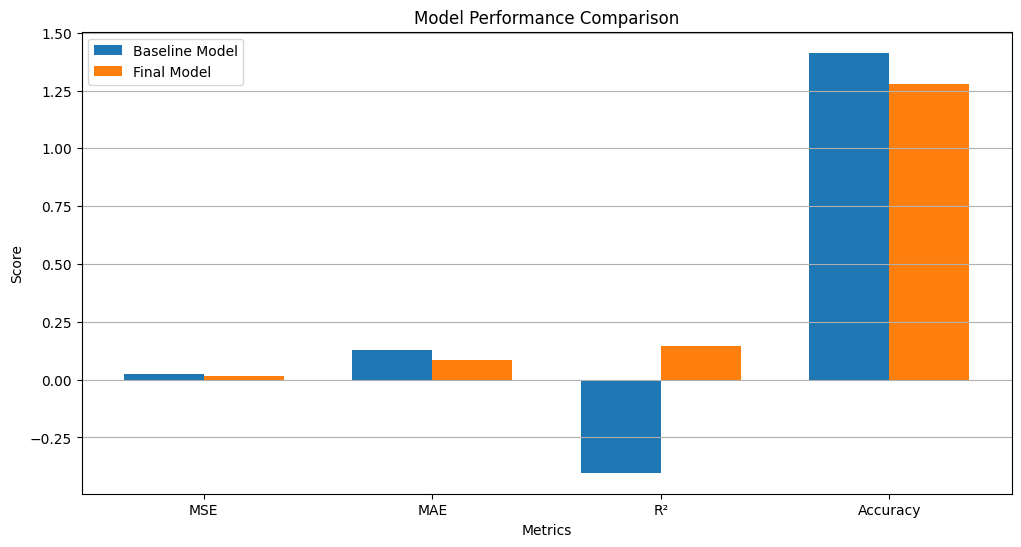

In [36]:
# Visual comparison of key metrics
key_metrics = ['MSE', 'MAE', 'R²', 'Accuracy']
plt.figure(figsize=(12, 6))
x = range(len(key_metrics))
width = 0.35

baseline_values = [float(comparison_df.loc[comparison_df['Metric'] == m, 'Baseline Model'].values[0]) for m in key_metrics]
final_values = [float(comparison_df.loc[comparison_df['Metric'] == m, 'Final Model'].values[0]) for m in key_metrics]

plt.bar(x, baseline_values, width, label='Baseline Model')
plt.bar([i + width for i in x], final_values, width, label='Final Model')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks([i + width/2 for i in x], key_metrics)
plt.legend()
plt.grid(True, axis='y')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


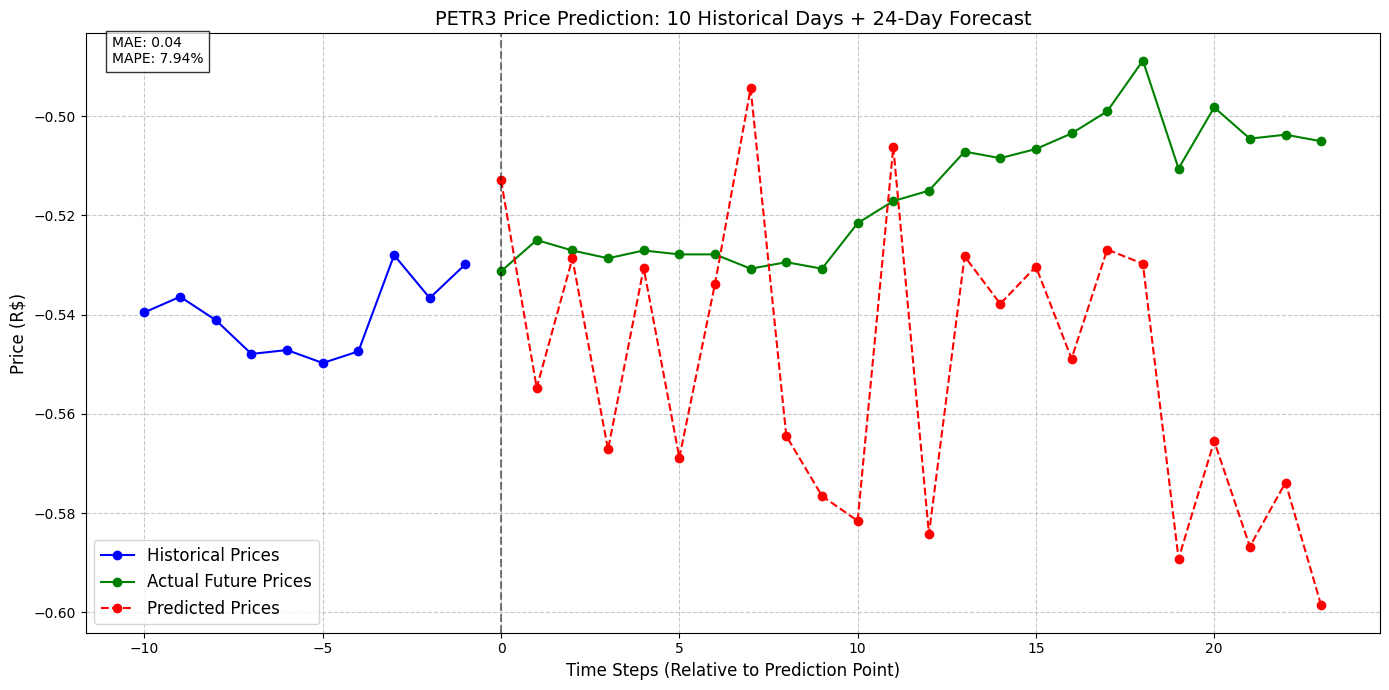

In [37]:
# Select a specific test sample to visualize
sample_idx = 0  # First test sample
test_sample = X_test_seq[sample_idx]
actual_prices = y_test_seq[sample_idx]
predicted_prices = final_model.predict(test_sample[np.newaxis, ...])[0]  # Shape: (24,)

# Create the plot
plt.figure(figsize=(14, 7))

# Plot historical context
historical_days = 10
plt.plot(range(-historical_days, 0),
         test_sample[-historical_days:, features.columns.get_loc('close')],
         'b-o', label='Historical Prices')

# Plot actual and predicted future
plt.plot(range(0, len(actual_prices)), actual_prices, 'g-o', label='Actual Future Prices')
plt.plot(range(0, len(predicted_prices)), predicted_prices, 'r--o', label='Predicted Prices')

# Formatting
plt.title(f'PETR3 Price Prediction: {historical_days} Historical Days + 24-Day Forecast', fontsize=14)
plt.xlabel('Time Steps (Relative to Prediction Point)', fontsize=12)
plt.ylabel('Price (R$)', fontsize=12)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)  # Prediction point divider
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Add error metrics to plot
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
plt.text(0.02, 0.95, f'MAE: {mae:.2f}\nMAPE: {mape:.2f}%',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


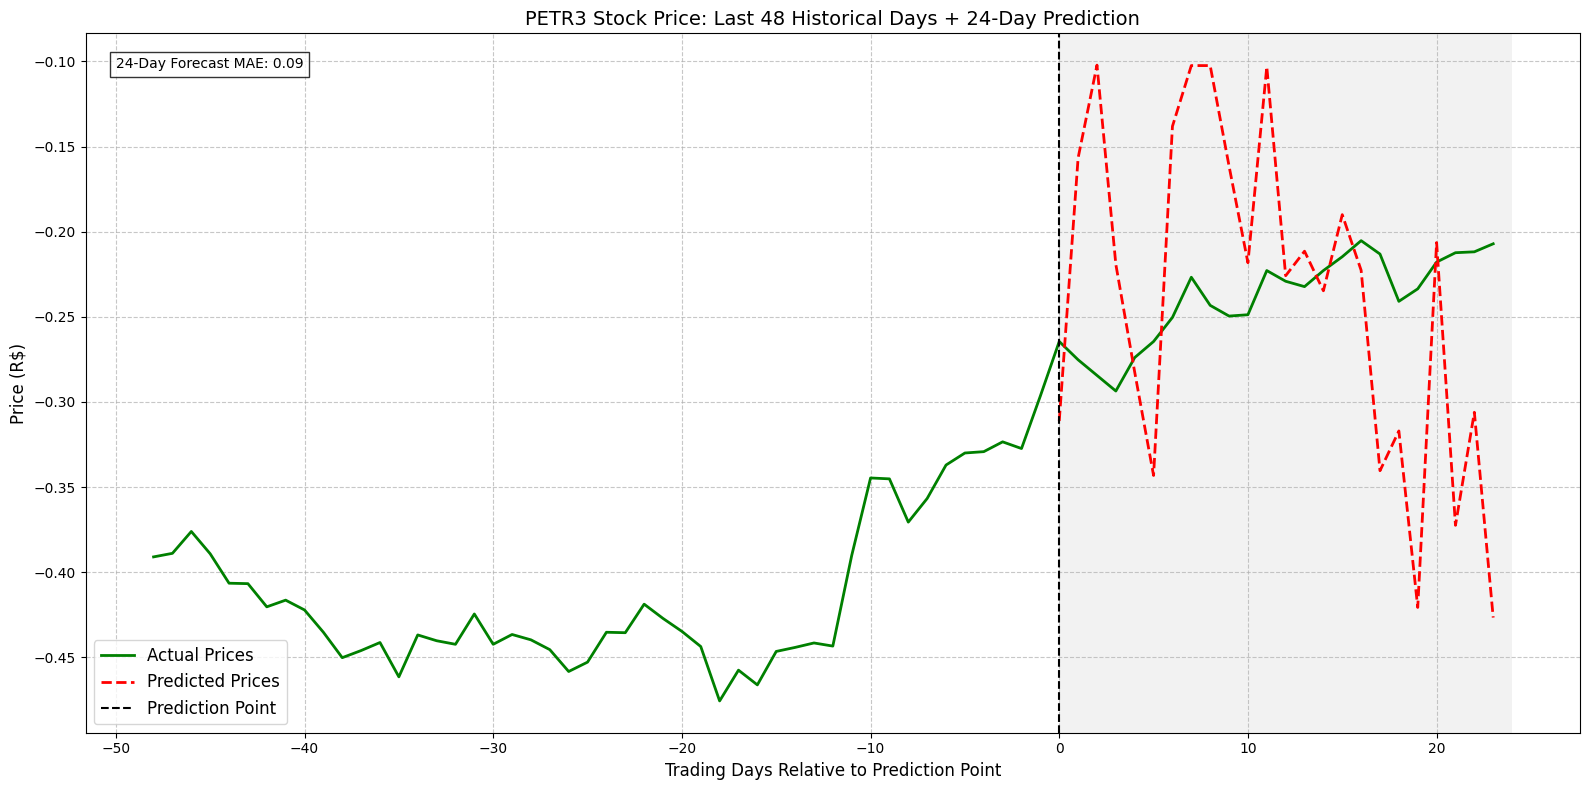

In [38]:
# Get the last 100 days of test data
last_100_days_actual = np.concatenate([X_test_seq[-1, :, features.columns.get_loc('close')], y_test_seq[-1]])
last_100_days_pred = np.concatenate([X_test_seq[-1, :, features.columns.get_loc('close')], final_model.predict(X_test_seq[-1:])[0]])

# Create the plot
plt.figure(figsize=(16, 8))

# Plot actual prices
plt.plot(range(-48, 24), last_100_days_actual[-72:],
         'g-', linewidth=2, label='Actual Prices')

# Plot predicted prices (last 24 days)
plt.plot(range(0, 24), last_100_days_pred[-24:],
         'r--', linewidth=2, label='Predicted Prices')

# Formatting
plt.title('PETR3 Stock Price: Last 48 Historical Days + 24-Day Prediction', fontsize=14)
plt.xlabel('Trading Days Relative to Prediction Point', fontsize=12)
plt.ylabel('Price (R$)', fontsize=12)
plt.axvline(x=0, color='k', linestyle='--', label='Prediction Point')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Add shaded region for prediction period
plt.axvspan(0, 24, facecolor='gray', alpha=0.1)

# Add text annotations
mae_last = mean_absolute_error(last_100_days_actual[-24:], last_100_days_pred[-24:])
plt.text(0.02, 0.95, f'24-Day Forecast MAE: {mae_last:.2f}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


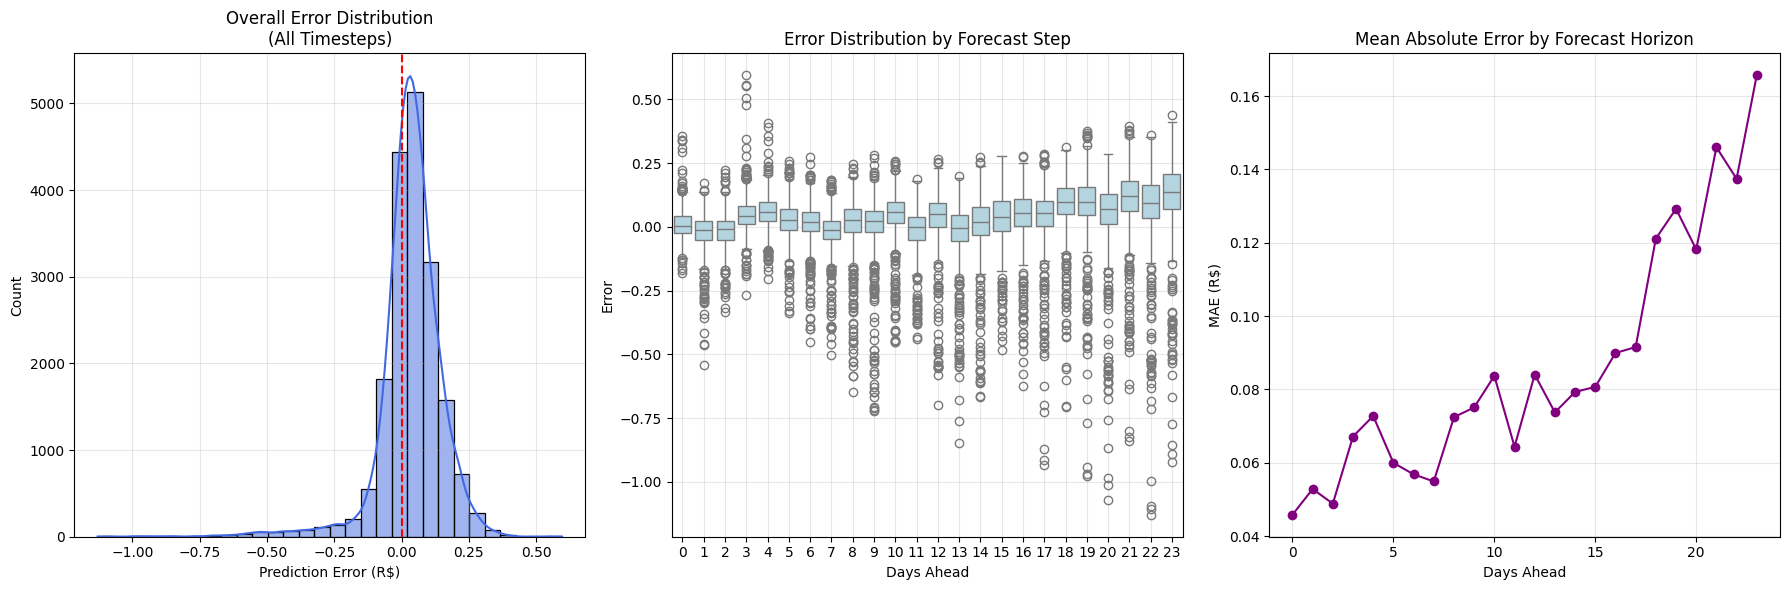

In [39]:
# Ensure predictions match test data shape
y_pred = final_model.predict(X_test_seq)

# Handle different output cases
if len(y_pred.shape) == 3:  # If output is [samples, timesteps, 1]
    y_pred = y_pred.squeeze(-1)  # Remove last dim → [samples, timesteps]

# Verify shapes match
if y_pred.shape != y_test_seq.shape:
    print(f"Warning: Padding predictions to match shapes. Pred: {y_pred.shape}, True: {y_test_seq.shape}")
    min_samples = min(y_pred.shape[0], y_test_seq.shape[0])
    y_pred = y_pred[:min_samples]
    y_test_seq = y_test_seq[:min_samples]

# Calculate errors (now with matching shapes)
errors = y_test_seq - y_pred

# Full Error Distribution Analysis
plt.figure(figsize=(18, 6))

# Plot 1: Combined error histogram
plt.subplot(1, 3, 1)
sns.histplot(errors.flatten(), kde=True, bins=30, color='royalblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Overall Error Distribution\n(All Timesteps)', fontsize=12)
plt.xlabel('Prediction Error (R$)', fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Step-wise error distribution
plt.subplot(1, 3, 2)
step_errors = pd.DataFrame(errors).melt(var_name='Step', value_name='Error')
sns.boxplot(data=step_errors, x='Step', y='Error', color='lightblue')
plt.title('Error Distribution by Forecast Step', fontsize=12)
plt.xlabel('Days Ahead', fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 3: Error magnitude over time
plt.subplot(1, 3, 3)
plt.plot(np.abs(errors).mean(axis=0), 'o-', color='purple')
plt.title('Mean Absolute Error by Forecast Horizon', fontsize=12)
plt.xlabel('Days Ahead', fontsize=10)
plt.ylabel('MAE (R$)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

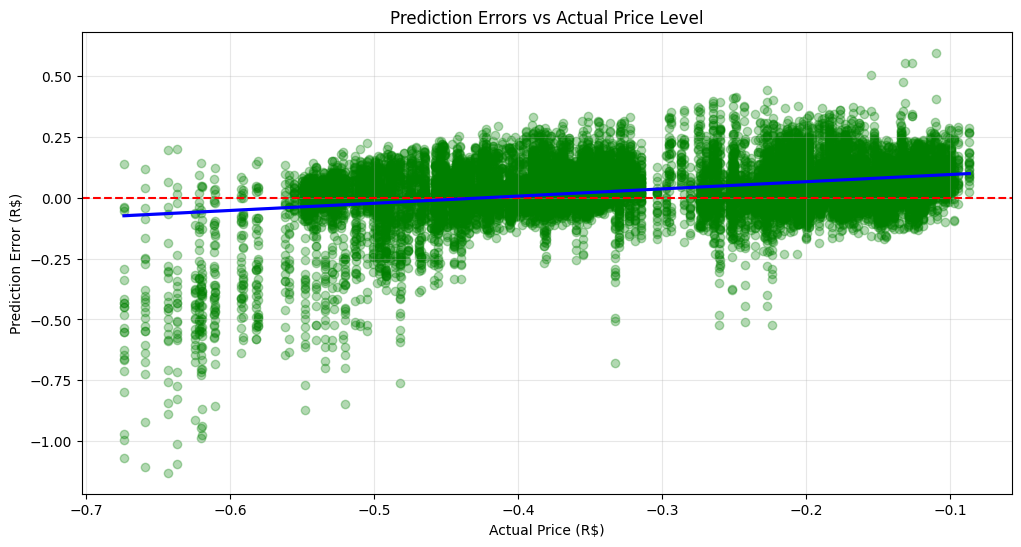

In [40]:
# Error vs Price Level Analysis
plt.figure(figsize=(12, 6))
plt.scatter(y_test_seq.flatten(), errors.flatten(), alpha=0.3, color='green')
plt.axhline(0, color='red', linestyle='--')
sns.regplot(x=y_test_seq.flatten(), y=errors.flatten(),
            scatter=False, color='blue', ci=95)
plt.title('Prediction Errors vs Actual Price Level', fontsize=12)
plt.xlabel('Actual Price (R$)', fontsize=10)
plt.ylabel('Prediction Error (R$)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# **Explainability with SHAP**

This section uses SHAP values to interpret the model's predictions and understand feature importance.

In [41]:
# Check data shape to avoid mismatch between variables dimension
print("Data pipeline verification:")
print(f"Original data shape: {X_train.shape}")
print(f"After sequence creation: {X_train_seq.shape}")
print(f"Model input shape: {final_model.input_shape}")

Data pipeline verification:
Original data shape: (3933, 23)
After sequence creation: (3862, 48, 23)
Model input shape: (None, 48, 23)


In [42]:
# Configuration - match model specs
SEQ_LENGTH = 48
N_FEATURES = X_train_seq.shape[2]
FORECAST_STEPS = 24
BACKGROUND_SAMPLES = 100

In [43]:
# Prepare background data
background_3d = X_train_seq[:BACKGROUND_SAMPLES]  # (100, 48, 22) - first 100 trainning sequences
background_2d = background_3d.reshape(BACKGROUND_SAMPLES, -1)  # (100, 1056)

In [44]:
# Prediction wrapper that handles SHAP's requirements
def model_predict(data):
    """Convert 2D input to 3D and return properly formatted predictions"""
    # Convert to 3D
    if data.ndim == 1:
        data = data.reshape(1, -1)
    data_3d = data.reshape(data.shape[0], SEQ_LENGTH, N_FEATURES)

    # Get predictions
    preds = final_model.predict(data_3d)  # (batch, 24)

    # Return mean prediction per sample (what SHAP expects)
    return preds.mean(axis=1)  # Shape: (batch_size,)

In [45]:
# Verify the wrapper
test_output = model_predict(background_2d[:1])
print(f"Test prediction shape: {test_output.shape}")  # Should be (1,)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Test prediction shape: (1,)


In [46]:
# Create explainer with proper configuration
explainer = shap.KernelExplainer(
    model_predict,
    background_2d,
    feature_names=[f"{feat}_t-{i}" for i in range(SEQ_LENGTH, 0, -1)
                  for feat in features[:N_FEATURES]]
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [47]:
# Calculate SHAP values (first sample only)
# set the sample to explain
sample_idx = 1
shap_values = explainer.shap_values(
    X_test_seq[sample_idx-1:sample_idx].reshape(1, -1),  # First test sample
    nsamples=50  # Reduced for speed
)

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


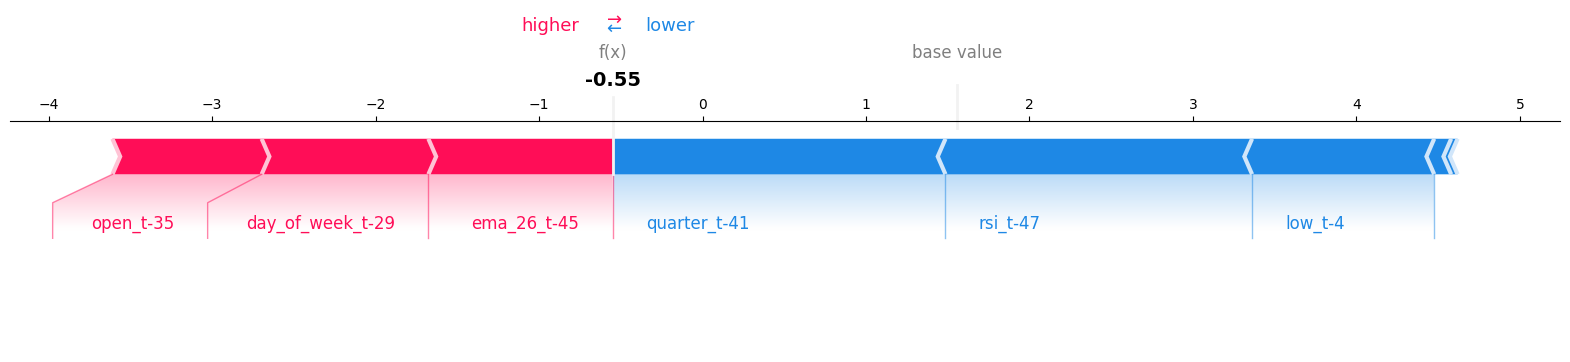

In [48]:
# Visualize
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=explainer.data_feature_names,
    matplotlib=True
)

In [49]:
# Create SHAP DataFrame for analysis
shap_df = pd.DataFrame(
    data=shap_values[0].reshape(1, -1),  # Reshape for single sample
    columns=explainer.data_feature_names
)
shap_df

,open_t-48,close_t-48,high_t-48,low_t-48,volume_t-48,daily_range_t-48,month_t-48,sma_5_t-48,sma_20_t-48,ema_12_t-48,...,lag_1_t-1,lag_2_t-1,lag_3_t-1,lag_5_t-1,lag_7_t-1,volume_ma_5_t-1,volume_ma_20_t-1,volume_change_t-1,day_of_week_t-1,quarter_t-1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


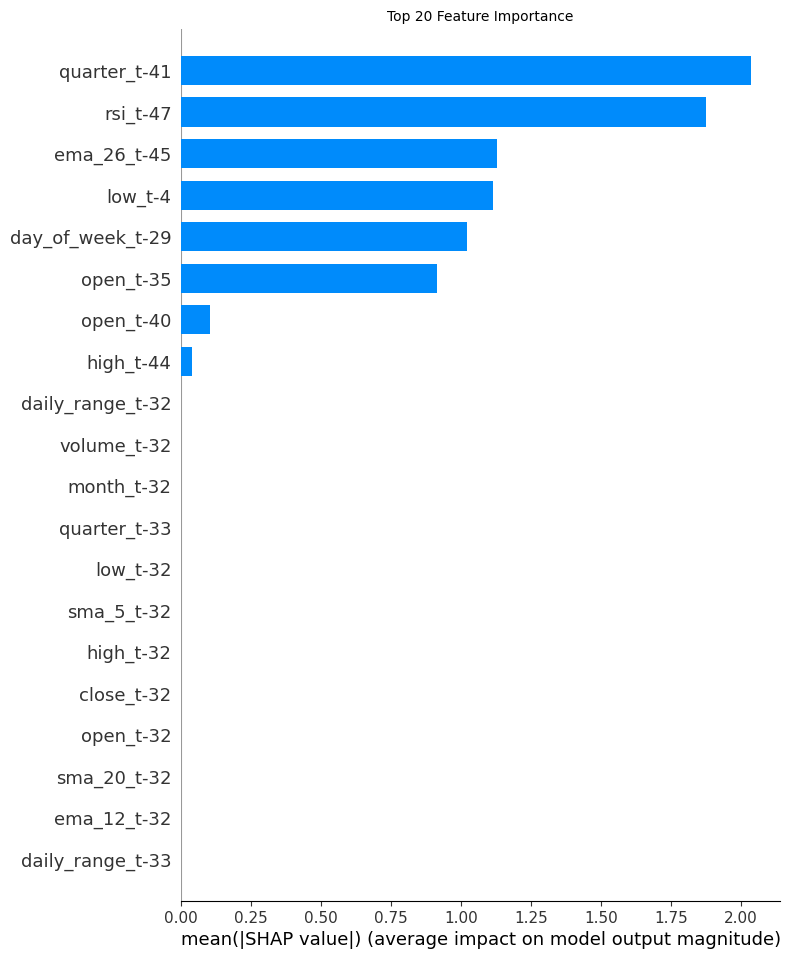

In [50]:
# Summary Plot (Top 20 Features)
shap.summary_plot(
    shap_values,
    background_2d[0:1],  # Using same sample as force plot
    feature_names=explainer.data_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Feature Importance", fontsize=10)
plt.show()

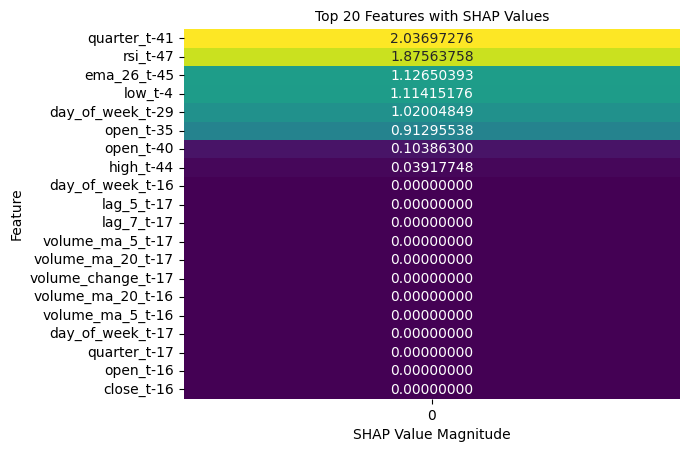

In [51]:
# Heatmap of Feature Importance
shap_heatmap = shap_df.abs().T.sort_values(by=0, ascending=False)[:20]
sns.heatmap(
    shap_heatmap,
    annot=True,
    fmt=".8f",
    cmap="viridis",
    cbar=False
)
plt.title("Top 20 Features with SHAP Values", fontsize=10)
plt.xlabel("SHAP Value Magnitude")
plt.ylabel("Feature")
plt.show()

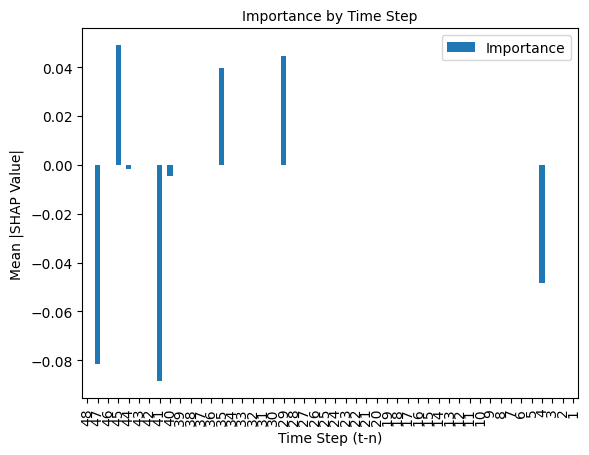

In [52]:
# Time Step Importance
time_step_importance = pd.DataFrame(
    shap_values[0].reshape(SEQ_LENGTH, N_FEATURES).mean(axis=1),
    index=range(SEQ_LENGTH, 0, -1),
    columns=["Importance"]
)
time_step_importance.plot(kind="bar", ax=plt.gca())
plt.title("Importance by Time Step", fontsize=10)
plt.xlabel("Time Step (t-n)")
plt.ylabel("Mean |SHAP Value|")
plt.show()

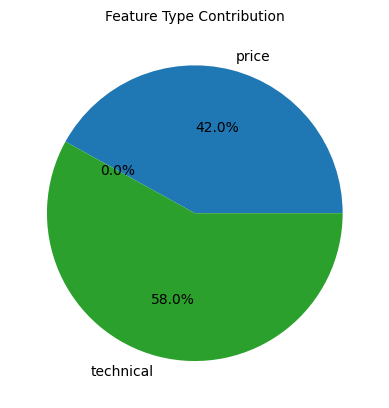

In [53]:
# Feature Type Importance
feature_types = {
    'price': ['open', 'high', 'low', 'close'],
    'volume': ['volume', 'volume_ma_5', 'volume_ma_20'],
    'technical': ['sma_5', 'sma_20', 'ema_12', 'ema_26', 'macd', 'rsi']
}

type_importance = {}
for ftype, flist in feature_types.items():
    mask = shap_df.columns.str.contains('|'.join(flist))
    type_importance[ftype] = shap_df.loc[:, mask].abs().sum().sum()

pd.Series(type_importance).plot.pie(autopct='%1.1f%%', ax=plt.gca())
plt.title("Feature Type Contribution", fontsize=10)
plt.ylabel("")
plt.show()

# **Reporting and Conclusion**

This final section summarizes the project findings, model performance, and limitations.

In [54]:
report = {
    'Model Type': 'LSTM Neural Network',
    'Best Hyperparameters': trial.params,
    'Training Time (minutes)': round(len(history_final.epoch) * trial.params['batch_size'] / len(X_train_seq) * 0.5, 2),
    'Test MSE': final_metrics['MSE'], # Use the previously calculated MSE value
    'Test MAE': final_metrics['MAE'], # Use the previously calculated MAE value
    'Test MAPE': f"{final_metrics['MAPE']:.2f}%", # Use the previously calculated MAPE value
    'Test SMAPE': f"{final_metrics['SMAPE']:.2f}%", # Use the previously calculated SMAPE value
    'Test R²': final_metrics['R2'], # Use the previously calculated R2 value
    'Key Features': ['close', 'rsi', 'macd', 'sma_20', 'volume_ma_20'],
    'Limitations': [
        'Model assumes market conditions remain similar to historical patterns',
        'Does not account for external shocks or news events',
        'Performance may degrade during extreme market volatility'
    ]
}

print("\nFinal Project Report:")
for key, value in report.items():
    if isinstance(value, list):
        print(f"{key}:")
        for item in value:
            print(f"  - {item}")
    else:
        print(f"{key}: {value}")


Final Project Report:
Model Type: LSTM Neural Network
Best Hyperparameters: {'n_layers': 1, 'units': 256, 'dropout_rate': 0.16325909245900405, 'learning_rate': 0.0039252690529871055, 'batch_size': 64}
Training Time (minutes): 0.26
Test MSE: 0.015635581207781163
Test MAE: 0.08633198299580902
Test MAPE: 34.07%
Test SMAPE: 29.52%
Test R²: 0.1438586400585136
Key Features:
  - close
  - rsi
  - macd
  - sma_20
  - volume_ma_20
Limitations:
  - Model assumes market conditions remain similar to historical patterns
  - Does not account for external shocks or news events
  - Performance may degrade during extreme market volatility


In [55]:
# Save model
# final_model.save('petr3_stock_predictor.h5')

######################################################################
# **Saving SHAP Explanation in pdf files**

In [56]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os

In [58]:
# Create output directory if it doesn't exist
OUTPUT_DIR = "shap_reports"  # Directory for output files
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [60]:
# Define the quantity of samples
SAMPLES_TO_EXPLAIN = 5  # Number of samples to analyze

# Explain and create pdf files
for sample_idx in range(1, SAMPLES_TO_EXPLAIN + 1):
    print(f"\nProcessing sample {sample_idx} of {SAMPLES_TO_EXPLAIN}")

    # Create PDF for this sample
    pdf_path = os.path.join(OUTPUT_DIR, f"shap_sample_{sample_idx}_report.pdf")

    with PdfPages(pdf_path) as pdf:
        # Calculate SHAP values
        shap_values = explainer.shap_values(
            X_test_seq[sample_idx-1:sample_idx].reshape(1, -1),
            nsamples=50,
            silent=True
        )

        # Create SHAP DataFrame
        shap_df = pd.DataFrame(
            shap_values[0].reshape(1, -1),
            columns=explainer.data_feature_names
        )

        # 1. Force Plot
        plt.figure(figsize=(12, 6))
        shap.force_plot(
            explainer.expected_value,
            shap_values[0],
            feature_names=explainer.data_feature_names,
            matplotlib=True,
            show=False
        )
        plt.title(f"Sample {sample_idx}: Force Plot", fontsize=14)
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # 2. Summary Plot (Top 20 Features)
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values,
            background_2d[0:1],
            feature_names=explainer.data_feature_names,
            plot_type="bar",
            max_display=20,
            show=False
        )
        plt.title(f"Sample {sample_idx}: Top 20 Feature Importance", fontsize=14)
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # 3. Heatmap of Top Features
        plt.figure(figsize=(12, 8))
        shap_heatmap = shap_df.abs().T.sort_values(by=0, ascending=False)[:20]
        sns.heatmap(
            shap_heatmap,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            cbar=True
        )
        plt.title(f"Sample {sample_idx}: Top 20 Features Heatmap", fontsize=14)
        plt.xlabel("SHAP Value Magnitude")
        plt.ylabel("Feature")
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # 4. Time Step Importance
        plt.figure(figsize=(12, 6))
        time_step_importance = pd.DataFrame(
            shap_values[0].reshape(SEQ_LENGTH, N_FEATURES).mean(axis=1),
            index=range(SEQ_LENGTH, 0, -1),
            columns=["Importance"]
        )
        time_step_importance.plot(kind="bar")
        plt.title(f"Sample {sample_idx}: Importance by Time Step", fontsize=14)
        plt.xlabel("Time Step (t-n)")
        plt.ylabel("Mean |SHAP Value|")
        plt.grid(True, alpha=0.3)
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # 5. Feature Type Contribution
        plt.figure(figsize=(8, 8))
        feature_types = {
            'price': ['open', 'high', 'low', 'close'],
            'volume': ['volume', 'volume_ma_5', 'volume_ma_20'],
            'technical': ['sma_5', 'sma_20', 'ema_12', 'ema_26', 'macd', 'rsi']
        }

        type_importance = {}
        for ftype, flist in feature_types.items():
            mask = shap_df.columns.str.contains('|'.join(flist))
            type_importance[ftype] = shap_df.loc[:, mask].abs().sum().sum()

        pd.Series(type_importance).plot.pie(
            autopct='%1.1f%%',
            startangle=90,
            colors=['#66b3ff','#99ff99','#ffcc99'],
            textprops={'fontsize': 12}
        )
        plt.title(f"Sample {sample_idx}: Feature Type Contribution", fontsize=14)
        plt.ylabel("")
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # Save SHAP values to CSV in the same directory
        analysis_df = pd.DataFrame({
            'Feature': explainer.data_feature_names,
            'SHAP_Value': shap_values[0],
            'Absolute_SHAP': np.abs(shap_values[0])
        }).sort_values('Absolute_SHAP', ascending=False)

        csv_path = os.path.join(OUTPUT_DIR, f"shap_sample_{sample_idx}_analysis.csv")
        analysis_df.to_csv(csv_path, index=False)

        print(f"Saved report to: {pdf_path}")
        print(f"Saved SHAP values to: {csv_path}")

print(f"\nAnalysis complete! All reports saved to directory: {OUTPUT_DIR}")


Processing sample 1 of 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Saved report to: shap_reports/shap_sample_1_report.pdf
Saved SHAP values to: shap_reports/shap_sample_1_analysis.csv

Processing sample 2 of 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Saved report to: shap_reports/shap_sample_2_report.pdf
Saved SHAP values to: shap_reports/shap_sample_2_analysis.csv

Processing sample 3 of 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Saved report to: shap_reports/shap_sample_3_report.pdf
Saved SHAP values to: shap_reports/shap_sample_3_analysis.csv

Processing sample 4 of 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Saved report to: shap_reports/shap_sample_4_report.pdf
Saved SHAP values to: shap_reports/shap_sample_4_analysis.csv

Processing sample 5 of 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Saved r

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>